In [7]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
import rasterio
from pathlib import Path
import gdal_tools

#model outputs
#path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/'
#path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/'


path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/"

#satelite dat
smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"
#Ndmi_sat = '/scratch/alpine/battobrah@xsede.org/landsat_ndmi/NORTHERN_NM_MONTHLY_PER_YEAR_2014_2024/'

print(path_pp)
print(path_3d)


outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/"

# ------------------------------------
# READ TIME FROM INPUT FILE (REQUIRED)
# ------------------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

# ------------------------------------
# BUILD DATETIME VECTOR (PROF STYLE)
# ------------------------------------
start = pd.Timestamp("2016-01-01 00:00")

datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")


# Read HRU grid + metadata (Read spatial rasters that map grid cells to HRUs)
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250     #trim off 250 pixels around the edges of the domain.
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)   # read cluster ids

# Force HRU count to match model outputs (1000)
with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):      # read raster grid
    with rasterio.open(fp) as ds:
        arr = ds.read(1).astype(np.float32)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr
      
def place_data(tmp, model, hrus, cids, val):    #tmp: an empty 2D grid template
    out = np.copy(tmp)                          #a 1D array of HRU values from the model
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru  = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/
/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


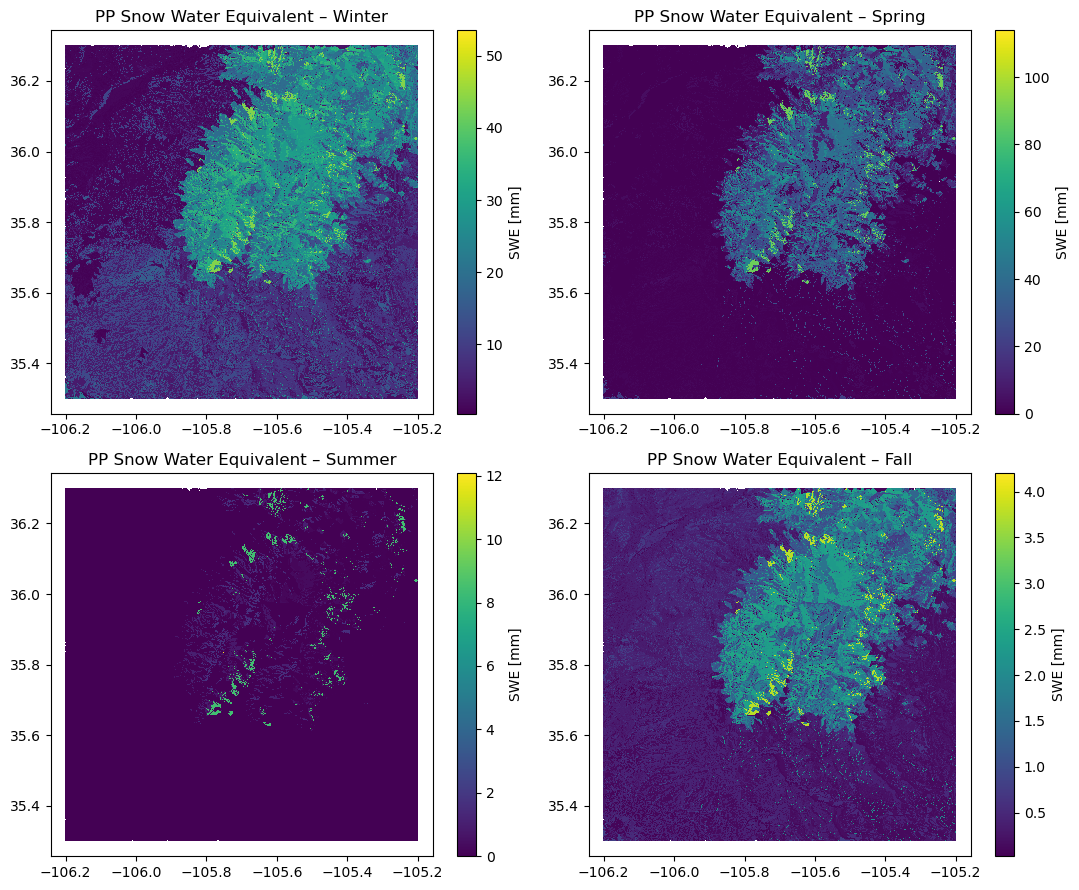

In [8]:
# SWE seasonal plots

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import os

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        swe = np.array(grp.variables["swe"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = swe[times_index, :]              # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Fresh template each time
        tmp = np.copy(hrus)
        tmp[:] = -9999.0

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid values
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map.astype(float)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"PP Snow Water Equivalent – {my_season}")
    fig.colorbar(im, ax=ax, label="SWE [mm]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_SWE_seasonal_pp.png"),
    dpi=300
)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


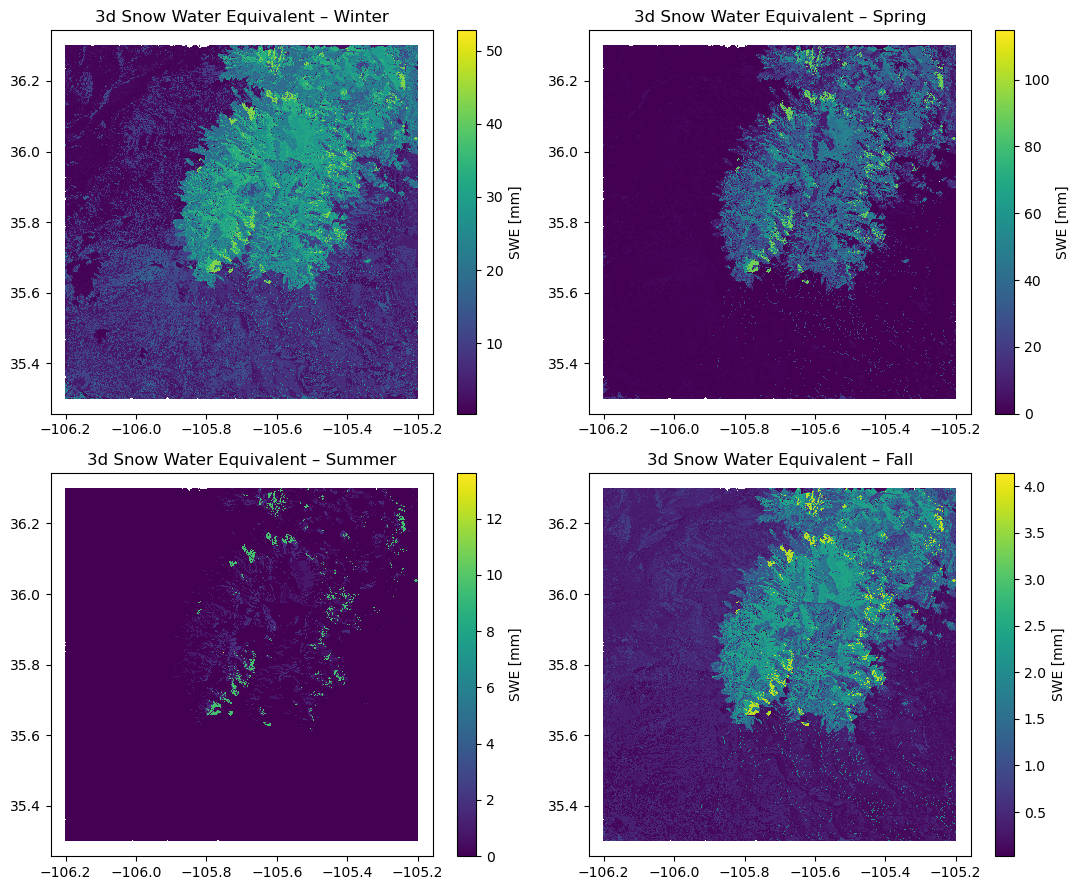

In [9]:
# SWE seasonal plots

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import os

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        swe = np.array(grp.variables["swe"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = swe[times_index, :]              # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Fresh template each time
        tmp = np.copy(hrus)
        tmp[:] = -9999.0

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid values
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map.astype(float)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"3d Snow Water Equivalent – {my_season}")
    fig.colorbar(im, ax=ax, label="SWE [mm]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_SWE_seasonal_3d.png"),
    dpi=300
)
plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


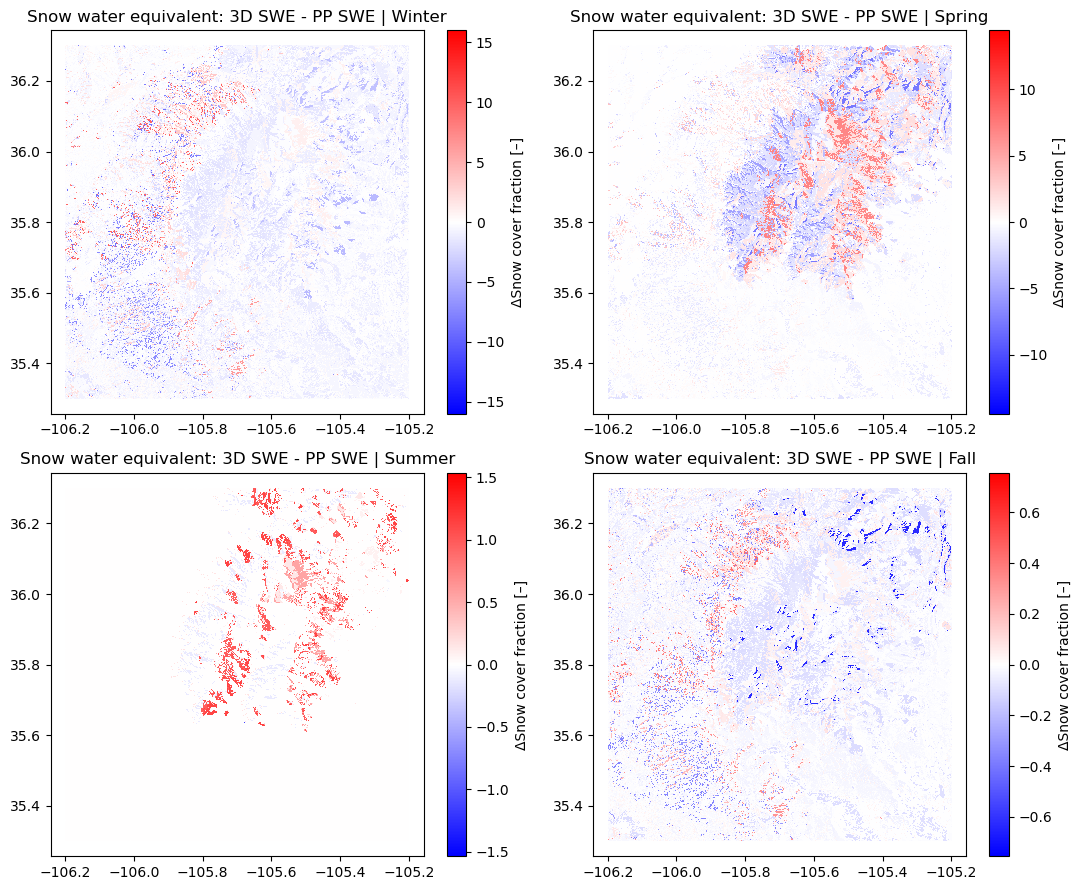

In [10]:
# 3D - PP seasonal difference maps (Snow water equivalent)
# Difference = 3D swe  -  PP swe

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("PP:", path_pp)

# use 3D domain for mapping (hrus/cids should match; we map both to the same grid)
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):     #seasons (0,1,2,3)
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # seasonal mask (same for both)
    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    # ----------------------------
    # 3D seasonal mean SWE (HRU)
    # ----------------------------
    fp_3d  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    swe_3d = np.array(grp_3d.variables["swe"][:])   # (time, hru)
    fp_3d.close()

    swe_3d_ave = np.nanmean(swe_3d[times_index, :], axis=0)  # (hru,)
    map_3d = place_data(tmp, swe_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # ----------------------------
    # PP seasonal mean SWE (HRU)
    # ----------------------------
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    swe_pp = np.array(grp_pp.variables["swe"][:])   # (time, hru)
    fp_pp.close()

    swe_pp_ave = np.nanmean(swe_pp[times_index, :], axis=0)  # (hru,)
    map_pp = place_data(tmp, swe_pp_ave, hrus, cids, 1)
    map_pp = np.where(map_pp == -9999, np.nan, map_pp)

    # ----------------------------
    # remove buffer (both)
    # ----------------------------
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]

    # difference: 3D - PP
    final_map = map_3d - map_pp

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow water equivalent: 3D SWE - PP SWE | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3D_minus_PP_SWE_maps.png"), dpi=300)
plt.show()


3D vs PP: Winter
3D vs PP: Spring
3D vs PP: Summer
3D vs PP: Fall


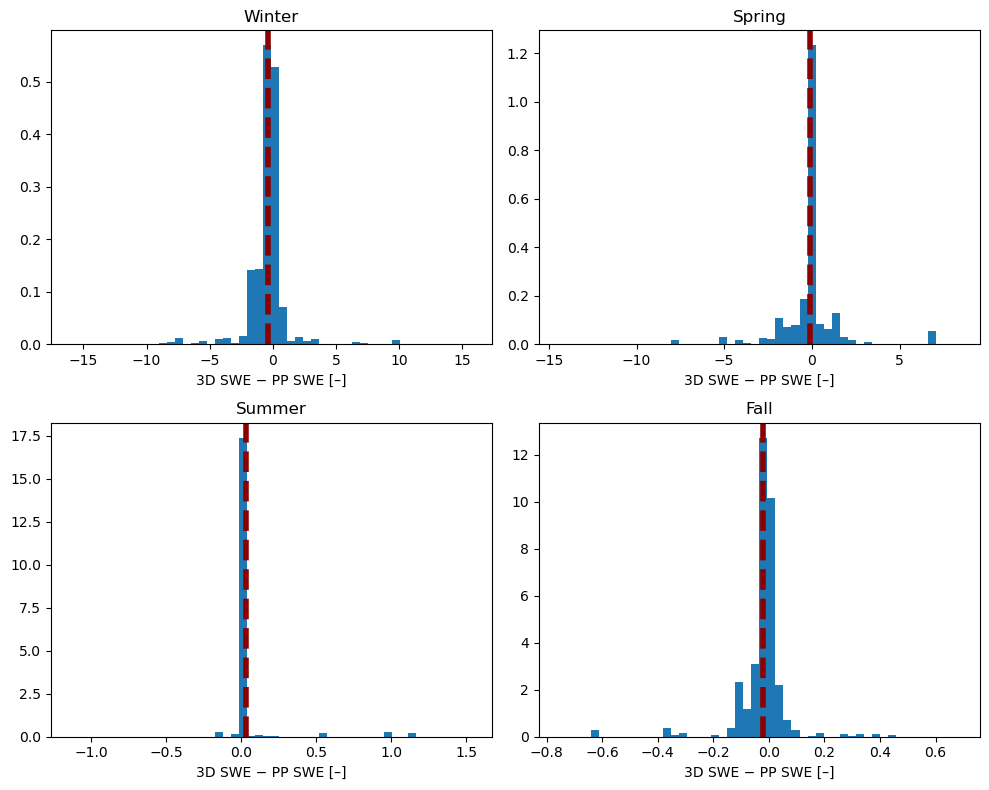

In [11]:
# 3D vs PP difference Histogram Plot (Snow cover fraction)
# Difference = 3D SWE - PP SWE

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # -------------------------
    # 3D seasonal mean SWE (HRU)
    # -------------------------
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    swe_3d = np.array(fp_3d.groups["data"].variables["swe"][:])  # (time, hru)
    fp_3d.close()
    swe_3d_mean = np.nanmean(swe_3d[idx, :], axis=0)

    # map 3D HRU → grid
    swe_3d_grid = place_data(tmp, swe_3d_mean, hrus, cids, 1)
    swe_3d_grid = np.where(swe_3d_grid == -9999, np.nan, swe_3d_grid)
    swe_3d_grid = swe_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # PP seasonal mean FSNO (HRU)
    # -------------------------
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    swe_pp = np.array(fp_pp.groups["data"].variables["swe"][:])  # (time, hru)
    fp_pp.close()
    swe_pp_mean = np.nanmean(swe_pp[idx, :], axis=0)

    # map PP HRU → grid (onto SAME grid)
    swe_pp_grid = place_data(tmp, swe_pp_mean, hrus, cids, 1)
    swe_pp_grid = np.where(swe_pp_grid == -9999, np.nan, swe_pp_grid)
    swe_pp_grid = swe_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    diff = swe_3d_grid - swe_pp_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D SWE − PP SWE [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_SWE_3D_minus_PP_SWE.png"),
    dpi=300
)
plt.show()


In [ ]:
EXTRACT STATIONS CLOSE TO HB DOMAIN

In [12]:
import pandas as pd

import os
os.environ['SNOTEL PATH'] = '/pl/active/snotelmodelling/snotel/'

from buildforcing.datasets import PNNLSnotel
# learn how to make functions or codes callable or a library

# Load station summary
stations = pd.read_csv(
    "/pl/active/snotelmodelling/snotel/bcqc_data_v2/SNOTEL_summary.csv"
)

# Domain bounds
lon_min = -106.45041666666549
lon_max = -104.94958333333221

lat_min = 35.049583333332606
lat_max = 36.55041666666588

# Select stations inside domain
stations_domain = stations[
    (stations["SNOTEL Lon ()"] >= lon_min) &
    (stations["SNOTEL Lon ()"] <= lon_max) &
    (stations["SNOTEL Lat ()"] >= lat_min) &
    (stations["SNOTEL Lat ()"] <= lat_max)
].copy()

# Reset index
stations_domain = stations_domain.reset_index(drop=True)

# Print results
print("Stations in domain:", len(stations_domain))

display(
    stations_domain[
        [
            "SNOTEL ID",
            "SNOTEL Name",
            "SNOTEL State",
            "SNOTEL Lat ()",
            "SNOTEL Lon ()",
            "SNOTEL Elev (ft)"
        ]
    ]
)

Stations in domain: 10


,SNOTEL ID,SNOTEL Name,SNOTEL State,SNOTEL Lat (),SNOTEL Lon (),SNOTEL Elev (ft)
0,1083,Tres Ritos,NM,36.13,-105.53,8600
1,1170,Palo,NM,36.41,-105.33,9350
2,1254,Rio Santa Barbara,NM,36.07,-105.63,10664
3,316,Bateman,NM,36.51,-106.32,9300
4,491,Gallegos Peak,NM,36.19,-105.56,9800
5,708,Quemazon,NM,35.92,-106.39,9500
6,854,Wesner Springs,NM,35.78,-105.54,11120
7,921,Elk Cabin,NM,35.70,-105.81,8210
8,922,Santa Fe,NM,35.77,-105.78,11445
9,934,Tolby,NM,36.47,-105.19,10180


In [13]:
from buildforcing.datasets import PNNLSnotel

In [14]:
import os
import pandas as pd

storage_path = "/pl/active/snotelmodelling/snotel/"
os.environ["SNOTEL PATH"] = storage_path

from buildforcing.datasets import PNNLSnotel

stations = pd.read_csv(
    "/pl/active/snotelmodelling/snotel/bcqc_data_v2/SNOTEL_summary.csv"
)

lon_min = -106.45041666666549
lon_max = -104.94958333333221
lat_min = 35.049583333332606
lat_max = 36.55041666666588

stations_domain = stations[
    (stations["SNOTEL Lon ()"] >= lon_min) &
    (stations["SNOTEL Lon ()"] <= lon_max) &
    (stations["SNOTEL Lat ()"] >= lat_min) &
    (stations["SNOTEL Lat ()"] <= lat_max)
].copy().reset_index(drop=True)

print("Stations in domain:", len(stations_domain))

station_file = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "SNOTEL_stations_in_HydroBlocks_domain.csv"
)

stations_domain.to_csv(station_file, index=False)
print("Saved:", station_file)

all_snotel = []

for _, row in stations_domain.iterrows():

    sid = int(row["SNOTEL ID"])
    sname = row["SNOTEL Name"]

    print("Reading:", sid, sname)

    try:
        st = PNNLSnotel(sid, storage_path)

        df = st.data.copy()
        df.columns = df.columns.str.lower().str.strip()
        df = df.reset_index()

        date_cols = [c for c in df.columns if "date" in c or "time" in c]
        date_col = date_cols[0] if len(date_cols) > 0 else df.columns[0]

        swe_cols = [c for c in df.columns if "swe" in c]

        if len(swe_cols) == 0:
            print("No SWE column found for:", sname)
            print(df.columns.tolist())
            continue

        swe_col = swe_cols[0]

        out = pd.DataFrame({
            "date": pd.to_datetime(df[date_col]).dt.tz_localize(None),
            "snotel_swe_raw": df[swe_col],
            "station": sname,
            "snotel_id": sid,
            "latitude": row["SNOTEL Lat ()"],
            "longitude": row["SNOTEL Lon ()"],
            "elev_ft": row["SNOTEL Elev (ft)"]
        })

        all_snotel.append(out)

    except Exception as e:
        print("FAILED:", sid, sname)
        print(e)

if len(all_snotel) == 0:
    raise RuntimeError("No SNOTEL data loaded.")

snotel_df = pd.concat(all_snotel, ignore_index=True)

print("Raw SWE range:")
print(snotel_df["snotel_swe_raw"].min(), snotel_df["snotel_swe_raw"].max())

if snotel_df["snotel_swe_raw"].max() < 100:
    print("Converting inches to mm")
    snotel_df["snotel_swe_mm"] = snotel_df["snotel_swe_raw"] * 25.4
else:
    print("Assuming SWE is already in mm")
    snotel_df["snotel_swe_mm"] = snotel_df["snotel_swe_raw"]

snotel_file = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "SNOTEL_daily_SWE_domain.csv"
)

snotel_df.to_csv(snotel_file, index=False)

print("Saved:", snotel_file)
print("Records:", len(snotel_df))
print("Stations saved:", snotel_df["station"].nunique())

Stations in domain: 10
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/SNOTEL_stations_in_HydroBlocks_domain.csv
Reading: 1083 Tres Ritos
FAILED: 1083 Tres Ritos
Site name 1083 not found in the PNNL Snotel metadata file.
Reading: 1170 Palo
FAILED: 1170 Palo
Site name 1170 not found in the PNNL Snotel metadata file.
Reading: 1254 Rio Santa Barbara
FAILED: 1254 Rio Santa Barbara
Site name 1254 not found in the PNNL Snotel metadata file.
Reading: 316 Bateman
FAILED: 316 Bateman
Site name 316 not found in the PNNL Snotel metadata file.
Reading: 491 Gallegos Peak
FAILED: 491 Gallegos Peak
Site name 491 not found in the PNNL Snotel metadata file.
Reading: 708 Quemazon
FAILED: 708 Quemazon
Site name 708 not found in the PNNL Snotel metadata file.
Reading: 854 Wesner Springs
FAILED: 854 Wesner Springs
Site name 854 not found in the PNNL Snotel metadata file.
Reading: 921 Elk Cabin
FAILED: 921 Elk Cabin
Site name 921 not found in the PNNL Snotel metadata file.
Reading: 922 San

RuntimeError: No SNOTEL data loaded.

In [ ]:
import os
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt

import geospatialtools.gdal_tools as gdal_tools

# --------------------------------------------------
# PATHS
# --------------------------------------------------
path_3d = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "experiments/simulations/"
    "MSWX_3h_Snow_Project3_3d_downscale_new/"
)

station_file = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "SNOTEL_stations_in_HydroBlocks_domain.csv"
)

snotel_file = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "SNOTEL_daily_SWE_domain.csv"
)

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/"
    "validation_plots/"
    "SNOTEL_SWE_compare"
)

os.makedirs(outputdir, exist_ok=True)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
stations_domain = pd.read_csv(
    station_file
)

snotel_df = pd.read_csv(
    snotel_file
)

snotel_df["date"] = pd.to_datetime(
    snotel_df["date"]
)

# --------------------------------------------------
# READ HRU MAP
# --------------------------------------------------
hrus = gdal_tools.read_raster(
    path_3d + "postprocess/hrus.vrt"
)

cids = gdal_tools.read_raster(
    path_3d + "postprocess/cids.vrt"
)

meta = gdal_tools.retrieve_metadata(
    path_3d + "postprocess/hrus.vrt"
)

buffer = 250

coord_x = np.linspace(
    meta["minx"],
    meta["maxx"],
    meta["nx"]
)

coord_y = np.linspace(
    meta["miny"],
    meta["maxy"],
    meta["ny"]
)

coords_x = coord_x[
    buffer:len(coord_x)-buffer+1
]

coords_y = coord_y[
    buffer:len(coord_y)-buffer+1
]

hrus_crop = hrus[
    buffer:hrus.shape[0]-buffer+1,
    buffer:hrus.shape[1]-buffer+1
]

# --------------------------------------------------
# MODEL SWE
# --------------------------------------------------
fp = nc.Dataset(
    path_3d +
    "output_data/1/2016-01-01.nc"
)

swe = np.array(
    fp.groups["data"].variables["swe"][:]
)

fp.close()

times = pd.date_range(
    "2016-01-01",
    periods=swe.shape[0],
    freq="3H"
)

swe_daily = pd.DataFrame(
    swe,
    index=times
).resample("D").mean()

# --------------------------------------------------
# EXTRACT MODEL SWE
# --------------------------------------------------
all_model = []

for _, row in stations_domain.iterrows():

    sid = int(row["SNOTEL ID"])
    sname = row["SNOTEL Name"]

    lon = row["SNOTEL Lon ()"]
    lat = row["SNOTEL Lat ()"]

    ix = np.argmin(
        np.abs(coords_x - lon)
    )

    iy = np.argmin(
        np.abs(coords_y - lat)
    )

    hru_id = int(
        hrus_crop[iy, ix]
    )

    if hru_id <= 0:
        continue

    model = pd.DataFrame()

    model["date"] = swe_daily.index

    model["model_swe_mm"] = (
        swe_daily.iloc[:, hru_id-1].values
    )

    model["station"] = sname
    model["snotel_id"] = sid

    all_model.append(model)

model_df = pd.concat(
    all_model,
    ignore_index=True
)

# --------------------------------------------------
# MERGE
# --------------------------------------------------
comparison = model_df.merge(
    snotel_df[
        [
            "date",
            "snotel_id",
            "snotel_swe_mm"
        ]
    ],
    on=["date","snotel_id"]
)

comparison.dropna(inplace=True)

# --------------------------------------------------
# METRICS
# --------------------------------------------------
model_all = comparison["model_swe_mm"].values
obs_all = comparison["snotel_swe_mm"].values

bias = np.mean(
    model_all - obs_all
)

rmse = np.sqrt(
    np.mean(
        (model_all - obs_all)**2
    )
)

mae = np.mean(
    np.abs(
        model_all - obs_all
    )
)

corr = np.corrcoef(
    model_all,
    obs_all
)[0,1]

pbias = (
    100 *
    np.sum(model_all - obs_all)
    /
    np.sum(obs_all)
)

print()
print("BIAS =", bias)
print("RMSE =", rmse)
print("MAE =", mae)
print("PBIAS =", pbias)
print("PEARSON r =", corr)

# --------------------------------------------------
# SCATTER
# --------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    obs_all,
    model_all,
    alpha=0.4
)

mx = max(
    obs_all.max(),
    model_all.max()
)

plt.plot(
    [0,mx],
    [0,mx],
    "k--"
)

plt.xlabel(
    "SNOTEL SWE [mm]"
)

plt.ylabel(
    "Model SWE [mm]"
)

plt.title(
    "HydroBlocks SWE vs SNOTEL"
)

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(
        outputdir,
        "SWE_scatter.png"
    ),
    dpi=300
)

plt.show()

In [1]:
import os
import time
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

# Full run: all 1600 CIDs
cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# START DASK
# ============================================================

client = Client(n_workers=8, threads_per_worker=1, processes=True)
print(client)

# ============================================================
# READ STATIC MAPS WITH RASTERIO
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

with rasterio.open(hrus_file) as src:
    hrus = src.read(1).astype(float)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(cids_file) as src:
    cids = src.read(1).astype(float)

coords_x = np.linspace(bounds.left, bounds.right, nx)
coords_y = np.linspace(bounds.bottom, bounds.top, ny)

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

season_masks = {
    seasons[i]: times.dt.month.isin(season_months[i]).values
    for i in range(len(seasons))
}

# ============================================================
# DASK FUNCTION: READ ONE CID ONCE
# ============================================================

@delayed
def process_one_cid(c, path, season_masks):

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        return c, None, np.inf, -np.inf

    with nc.Dataset(fp_path) as fp:
        smc_top = np.array(fp.groups["data"].variables["smc"][:, :, 0])

    seasonal_means = {}
    cid_min = np.inf
    cid_max = -np.inf

    for season, smask in season_masks.items():
        data_ave = np.nanmean(smc_top[smask, :], axis=0)

        seasonal_means[season] = data_ave

        cid_min = min(cid_min, np.nanmin(data_ave))
        cid_max = max(cid_max, np.nanmax(data_ave))

    return c, seasonal_means, cid_min, cid_max

# ============================================================
# RUN DASK TASKS
# ============================================================

tasks = [
    process_one_cid(c, path, season_masks)
    for c in cid_list
]

t0 = time.time()
results = compute(*tasks)
print(f"Dask compute took {(time.time() - t0) / 60:.2f} minutes")

# ============================================================
# CREATE SEASONAL MAPS
# ============================================================

season_maps = {
    season: np.full(hrus.shape, -9999.0, dtype=np.float32)
    for season in seasons
}

global_min = np.inf
global_max = -np.inf

for c, seasonal_means, cid_min, cid_max in results:

    if seasonal_means is None:
        print(f"Missing CID {c}")
        continue

    if c % 100 == 0:
        print(f"Mapping CID {c}")

    mask = (hrus != -9999) & (cids == int(c))

    if not np.any(mask):
        continue

    hru_idx = hrus[mask].astype(int)

    for season in seasons:
        season_maps[season][mask] = seasonal_means[season][hru_idx]

    global_min = min(global_min, cid_min)
    global_max = max(global_max, cid_max)

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT EACH SEASON SEPARATELY
# ============================================================

for season in seasons:

    print(f"Plotting {season}")

    final_map = np.ma.masked_where(
        season_maps[season] == -9999,
        season_maps[season]
    )

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        np.flipud(final_map),
        extent=[
            coords_x.min(),
            coords_x.max(),
            coords_y.min(),
            coords_y.max()
        ],
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="none"
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

    plt.tight_layout()

    outfile = os.path.join(
        outputdir,
        f"res_smc_surface_PP_100hru_100bh_{season.lower()}_global_scale_fullres.png"
    )

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print("Saved:", outfile)

    plt.close(fig)

client.shutdown()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45247 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:32823' processes=8 threads=8, memory=15.00 GiB>
Dask compute took 3.45 minutes
Mapping CID 100
Mapping CID 200
Mapping CID 300
Mapping CID 400
Mapping CID 500
Mapping CID 600
Mapping CID 700
Mapping CID 800
Mapping CID 900
Mapping CID 1000
Mapping CID 1100
Mapping CID 1200
Mapping CID 1300
Mapping CID 1400
Mapping CID 1500
Mapping CID 1600
Global SMC min: 0.025376873
Global SMC max: 0.5868258
Plotting Winter


: 

: 

In [1]:
import os
import time
import gc
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# START DASK
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    processes=True,
    memory_limit="10GB"
)

print(client)

# ============================================================
# READ STATIC MAPS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

with rasterio.open(hrus_file) as src:
    hrus = src.read(1).astype(np.float32)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(cids_file) as src:
    cids = src.read(1).astype(np.float32)

coords_x = np.linspace(bounds.left, bounds.right, nx)
coords_y = np.linspace(bounds.bottom, bounds.top, ny)

# valid map extent only once
valid_domain = (hrus != -9999) & np.isfinite(hrus)
rows_domain, cols_domain = np.where(valid_domain)

xmin = coords_x[cols_domain.min()]
xmax = coords_x[cols_domain.max()]
ymin = coords_y[rows_domain.min()]
ymax = coords_y[rows_domain.max()]

pad_x = 0.02 * (xmax - xmin)
pad_y = 0.02 * (ymax - ymin)

# ============================================================
# READ TIME
# ============================================================

with nc.Dataset(path + "1/input_file.nc") as fp:
    time_var = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

season_masks = {
    seasons[i]: times.dt.month.isin(season_months[i]).values
    for i in range(len(seasons))
}

# ============================================================
# DASK FUNCTION
# ============================================================

@delayed
def process_one_cid(c, path, season_masks):

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        return c, None, np.inf, -np.inf

    with nc.Dataset(fp_path) as fp:
        smc_top = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    seasonal_means = {}
    cid_min = np.inf
    cid_max = -np.inf

    for season, smask in season_masks.items():

        data_ave = np.nanmean(smc_top[smask, :], axis=0).astype(np.float32)

        seasonal_means[season] = data_ave

        cid_min = min(cid_min, float(np.nanmin(data_ave)))
        cid_max = max(cid_max, float(np.nanmax(data_ave)))

    del smc_top

    return c, seasonal_means, cid_min, cid_max

# ============================================================
# RUN DASK
# ============================================================

tasks = [
    process_one_cid(c, path, season_masks)
    for c in cid_list
]

t0 = time.time()
results = compute(*tasks)

print(f"Dask compute took {(time.time() - t0) / 60:.2f} minutes")

# ============================================================
# CREATE SEASONAL MAPS
# ============================================================

season_maps = {
    season: np.full(hrus.shape, -9999.0, dtype=np.float32)
    for season in seasons
}

global_min = np.inf
global_max = -np.inf

for c, seasonal_means, cid_min, cid_max in results:

    if seasonal_means is None:
        print(f"Missing CID {c}")
        continue

    if c % 100 == 0:
        print(f"Mapping CID {c}")

    mask = (hrus != -9999) & (cids == int(c))

    if not np.any(mask):
        continue

    hru_idx = hrus[mask].astype(int)

    for season in seasons:
        season_maps[season][mask] = seasonal_means[season][hru_idx]

    global_min = min(global_min, cid_min)
    global_max = max(global_max, cid_max)

del results
gc.collect()

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT EACH SEASON SAFELY
# ============================================================

for season in seasons:

    print(f"Plotting {season}")

    arr = season_maps[season].copy()
    arr[arr == -9999] = np.nan

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        np.flipud(arr),
        extent=[
            coords_x.min(),
            coords_x.max(),
            coords_y.min(),
            coords_y.max()
        ],
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_title(f"PP Surface soil moisture 0–5 cm - {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

    outfile = os.path.join(
        outputdir,
        f"res_smc_surface_PP_100hru_100bh_{season.lower()}_global_scale_fullres.png"
    )

    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    print("Saved:", outfile)

    plt.close(fig)

    del arr
    gc.collect()

client.shutdown()

print("Done.")

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
<Client: 'tcp://127.0.0.1:43179' processes=8 threads=8, memory=52.15 GiB>


In [1]:
import os
import time
import gc
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# START DASK
# ============================================================

client = Client(
    n_workers=4,
    threads_per_worker=1,
    processes=True,
    memory_limit="7GB"
)
print(client)

# ============================================================
# READ STATIC MAPS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

with rasterio.open(hrus_file) as src:
    hrus = src.read(1).astype(np.float32)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(cids_file) as src:
    cids = src.read(1).astype(np.float32)

coords_x = np.linspace(bounds.left, bounds.right, nx)
coords_y = np.linspace(bounds.bottom, bounds.top, ny)

# ============================================================
# READ TIME
# ============================================================

with nc.Dataset(path + "1/input_file.nc") as fp:
    time_var = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

season_masks = {
    seasons[i]: times.dt.month.isin(season_months[i]).values
    for i in range(len(seasons))
}

# ============================================================
# DASK FUNCTION
# ============================================================

@delayed
def process_one_cid(c, path, season_masks):

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        return c, None, np.inf, -np.inf

    with nc.Dataset(fp_path) as fp:
        smc_top = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    seasonal_means = {}
    cid_min = np.inf
    cid_max = -np.inf

    for season, smask in season_masks.items():
        data_ave = np.nanmean(smc_top[smask, :], axis=0).astype(np.float32)
        seasonal_means[season] = data_ave

        cid_min = min(cid_min, float(np.nanmin(data_ave)))
        cid_max = max(cid_max, float(np.nanmax(data_ave)))

    del smc_top

    return c, seasonal_means, cid_min, cid_max

# ============================================================
# RUN DASK
# ============================================================

tasks = [
    process_one_cid(c, path, season_masks)
    for c in cid_list
]

t0 = time.time()
results = compute(*tasks)

print(f"Dask compute took {(time.time() - t0) / 60:.2f} minutes")

# ============================================================
# CREATE SEASONAL MAPS
# ============================================================

season_maps = {
    season: np.full(hrus.shape, -9999.0, dtype=np.float32)
    for season in seasons
}

global_min = np.inf
global_max = -np.inf

for c, seasonal_means, cid_min, cid_max in results:

    if seasonal_means is None:
        print(f"Missing CID {c}")
        continue

    if c % 100 == 0:
        print(f"Mapping CID {c}")

    mask = (hrus != -9999) & (cids == int(c))

    if not np.any(mask):
        continue

    hru_idx = hrus[mask].astype(int)

    for season in seasons:
        season_maps[season][mask] = seasonal_means[season][hru_idx]

    global_min = min(global_min, cid_min)
    global_max = max(global_max, cid_max)

del results, tasks
gc.collect()
client.shutdown()

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# FIND VALID EXTENT
# ============================================================

valid_domain = (hrus != -9999) & np.isfinite(hrus)
rows_domain, cols_domain = np.where(valid_domain)

xmin = coords_x[cols_domain.min()]
xmax = coords_x[cols_domain.max()]
ymin = coords_y[rows_domain.min()]
ymax = coords_y[rows_domain.max()]

pad_x = 0.02 * (xmax - xmin)
pad_y = 0.02 * (ymax - ymin)

# ============================================================
# SAVE EACH SEASON SEPARATELY
# ============================================================

saved_files = []

for season in seasons:

    print(f"Plotting {season}")

    arr = season_maps[season].copy()
    arr[arr == -9999] = np.nan

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        np.flipud(arr),
        extent=[
            coords_x.min(),
            coords_x.max(),
            coords_y.min(),
            coords_y.max()
        ],
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_title(f"PP Surface soil moisture 0–5 cm - {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

    outfile = os.path.join(
        outputdir,
        f"res_smc_surface_PP_100hru_100bh_{season.lower()}_global_scale_fullres.png"
    )

    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    print("Saved:", outfile)

    saved_files.append(outfile)

    plt.close(fig)

    del arr, fig, ax, im
    gc.collect()

# ============================================================
# COMBINE SAVED PNGS INTO ONE 2x2 PANEL
# ============================================================

print("Creating combined 2x2 panel")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, season, pngfile in zip(axes, seasons, saved_files):

    img = plt.imread(pngfile)

    ax.imshow(img)
    ax.set_title(season)
    ax.axis("off")

plt.suptitle(
    "PP Surface soil moisture 0–5 cm - All Seasons",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

combined_file = os.path.join(
    outputdir,
    "res_smc_surface_PP_100hru_100bh_all_seasons_2x2_panel.png"
)

fig.savefig(combined_file, dpi=200, bbox_inches="tight")
print("Saved combined panel:", combined_file)

plt.close(fig)
gc.collect()

print("Done.")

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36831 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:34625' processes=4 threads=4, memory=26.08 GiB>


In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# READ RASTERS AND METADATA
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = [times.dt.month.isin(months).values for months in season_months]

# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = [np.full(hrus.shape, -9999.0, dtype=np.float64) for _ in seasons]

# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = np.inf
global_max = -np.inf

for c in cid_list:
    try:
        fp_path = os.path.join(path, f"output_data/{c}/2014-01-01.nc")
        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        with nc.Dataset(fp_path) as fp:
            # Read only top soil layer: 0–5 cm
            smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

        for iss in range(len(seasons)):
            data_sel = smc[season_masks[iss], :]
            data_ave = np.nanmean(data_sel, axis=0).astype(np.float64)

            global_min = min(global_min, np.nanmin(data_ave))
            global_max = max(global_max, np.nanmax(data_ave))

            mask = (hrus != -9999) & (cids == int(c))
            season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

        if c % 100 == 0:
            print(f"Finished CID {c}")

    except Exception as e:
        print(f"Error processing CID {c}: {e}")

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    final_map = np.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    if valid.any():  # Check if there are valid data points
        xmin = coords_x[cols.min()]
        xmax = coords_x[cols.max()]
        ymin = coords_y[rows.min()]
        ymax = coords_y[rows.max()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map),
            cmap="viridis",
            shading="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# READ RASTERS AND METADATA
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = [times.dt.month.isin(months).values for months in season_months]

# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = [np.full(hrus.shape, -9999.0, dtype=np.float64) for _ in seasons]

# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = np.inf
global_max = -np.inf

for c in cid_list:
    try:
        fp_path = os.path.join(path, f"output_data/{c}/2014-01-01.nc")
        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        with nc.Dataset(fp_path) as fp:
            # Read only top soil layer: 0–5 cm
            smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

        for iss in range(len(seasons)):
            data_sel = smc[season_masks[iss], :]
            data_ave = np.nanmean(data_sel, axis=0).astype(np.float64)

            global_min = min(global_min, np.nanmin(data_ave))
            global_max = max(global_max, np.nanmax(data_ave))

            mask = (hrus != -9999) & (cids == int(c))
            season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

        if c % 100 == 0:
            print(f"Finished CID {c}")

    except Exception as e:
        print(f"Error processing CID {c}: {e}")

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    final_map = np.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    if valid.any():  # Check if there are valid data points
        xmin = coords_x[cols.min()]
        xmax = coords_x[cols.max()]
        ymin = coords_y[rows.min()]
        ymax = coords_y[rows.max()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map),
            cmap="viridis",
            shading="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Total timesteps: 32120
First time: 2014-01-01 00:00:00
Last time : 2024-12-28 21:00:00
Winter timesteps: 472
season_index sum: 472
smc shape: (32120, 100)
selected shape: (472, 100)
data min: 0.08180573
data max: 0.21285546
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Proce

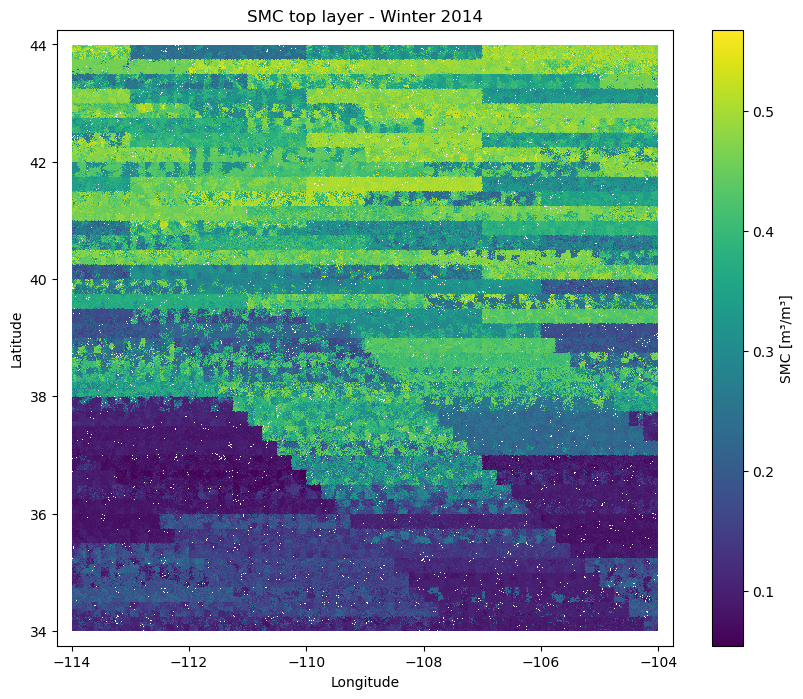

In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# paths

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# read hru and cid maps

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)

metad = gdal_tools.retrieve_metadata(hrus_file)
extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# settings

var = "smc"
season_name = "Winter"
season_months = (1, 2)   # Jan-Feb 2014 only, since Dec 2013 is not in this run
cid_list = range(1, 1601)

# read time from input file

time_file = path + "1/input_file.nc"

with nc.Dataset(time_file) as fp:
    time = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin(season_months))
).values

print("Total timesteps:", len(times))
print("First time:", times.iloc[0])
print("Last time :", times.iloc[-1])
print(f"{season_name} timesteps:", season_index.sum())

# map smc values to raster

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    with nc.Dataset(fp_path) as fp:

        grp = fp.groups["data"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            continue

        # smc(time, hru, soil)
        smc = np.array(grp.variables[var][:, :, 0], dtype=np.float32)

    smc[smc <= -9990] = np.nan

    # seasonal mean by HRU
    data = np.nanmean(smc[season_index, :], axis=0)

    if cid == 1:
        print("season_index sum:", season_index.sum())
        print("smc shape:", smc.shape)
        print("selected shape:", smc[season_index, :].shape)
        print("data min:", np.nanmin(data))
        print("data max:", np.nanmax(data))

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)

    # important correction:
    # HRU IDs are usually 1-based, but Python indexing is 0-based
    hru_index = hru_ids - 1

    valid = (hru_index >= 0) & (hru_index < len(data))

    rows, cols = np.where(mask)

    final_map[rows[valid], cols[valid]] = data[hru_index[valid]]

final_map[final_map == -9999.0] = np.nan

print("Final valid pixels:", np.sum(np.isfinite(final_map)))
print("Final min:", np.nanmin(final_map))
print("Final max:", np.nanmax(final_map))

# plot

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name} 2014")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"smc_top_layer_{season_name}_2014_100hru_full_domain_corrected.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()